Author [Maxime Devanne](https://maxime-devanne.com)

# Regression with multi-layers perceptrons

## Import libraries

In [ ]:
# Use seaborn for pairplot.
!pip install -q seaborn

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Make NumPy printouts easier to read.
np.set_printoptions(precision=3, suppress=True)

In [ ]:
import tensorflow as tf

print(tf.__version__)

2.19.0


## Auto MPG dataset

Available here: [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/).


### Get data
We can for instance use pandas

In [ ]:
url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'
column_names = ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight',
                'Acceleration', 'Model Year', 'Origin']

raw_dataset = pd.read_csv(url, names=column_names,
                          na_values='?', comment='\t',
                          sep=' ', skipinitialspace=True)

We print some rows to observe data

In [ ]:
dataset = raw_dataset.copy()
dataset.tail()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
393,27.0,4,140.0,86.0,2790.0,15.6,82,1
394,44.0,4,97.0,52.0,2130.0,24.6,82,2
395,32.0,4,135.0,84.0,2295.0,11.6,82,1
396,28.0,4,120.0,79.0,2625.0,18.6,82,1
397,31.0,4,119.0,82.0,2720.0,19.4,82,1


### Data cleaning

The dataset contains 'nan' values for the attribute `"Horsepower"`.

We remove corresponding rows.

In [ ]:
dataset = dataset.dropna()
dataset.shape

(392, 8)

The attribute `"Origin"` corresponds to a categorical value (country of origine) and not a numerical value. To favor the training procedure, we need to transform this attribute into a one-hot vector. We could use [pd.get_dummies](https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html).

In [ ]:
dataset['Origin'] = dataset['Origin'].map({1: 'USA', 2: 'Europe', 3: 'Japan'})
dataset = pd.get_dummies(dataset, columns=['Origin'], prefix='', prefix_sep='')
dataset.tail()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Europe,Japan,USA
393,27.0,4,140.0,86.0,2790.0,15.6,82,False,False,True
394,44.0,4,97.0,52.0,2130.0,24.6,82,True,False,False
395,32.0,4,135.0,84.0,2295.0,11.6,82,False,False,True
396,28.0,4,120.0,79.0,2625.0,18.6,82,False,False,True
397,31.0,4,119.0,82.0,2720.0,19.4,82,False,False,True


### Training set and Test set

We can split the dataset into a training set and a test set.

In [ ]:
train_dataset = dataset.sample(frac=0.8, random_state=0)
test_dataset = dataset.drop(train_dataset.index)
print(train_dataset.shape,test_dataset.shape)

(314, 10) (78, 10)


### Data inspection

An important step, before starting the training procedure, is to inspect the data. For instance, it can be interesting to analyze the joint distribution between pair of attributes. With the seaborn library, we can easily fo that with the `pairplot()` function.

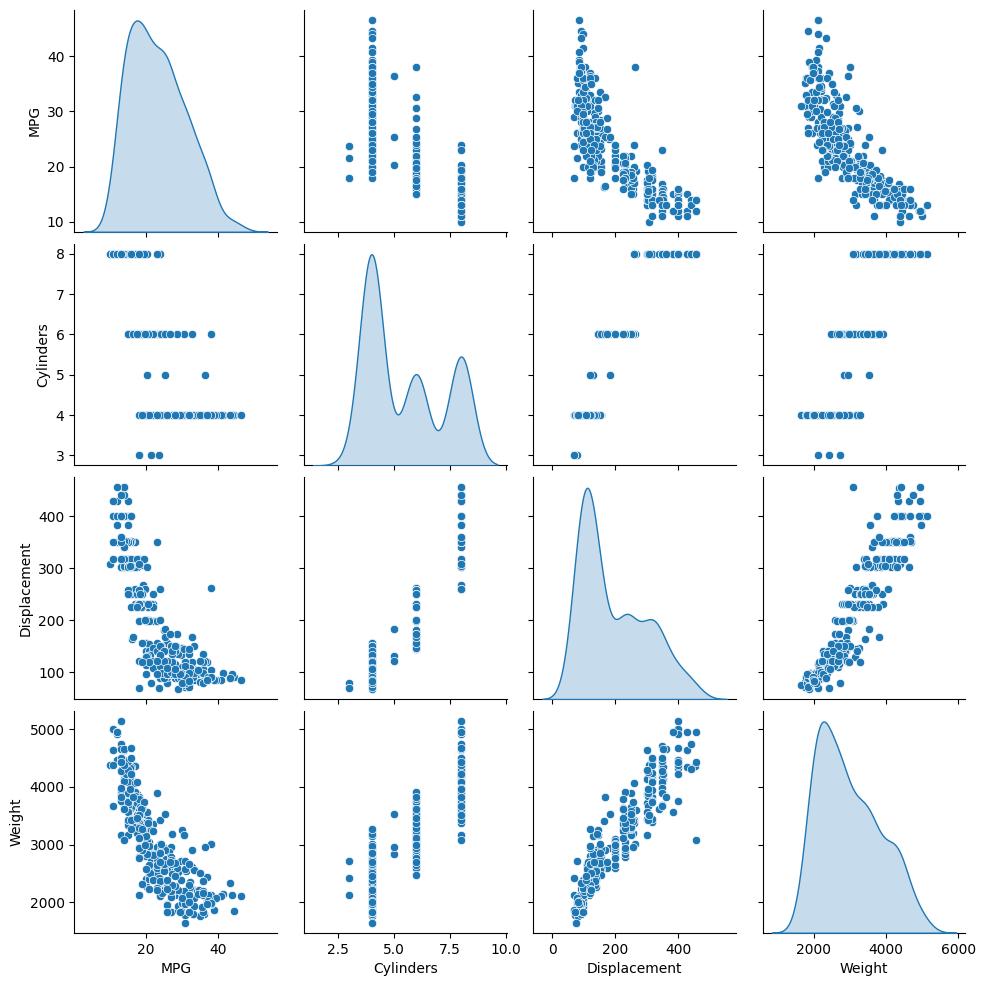

In [ ]:
sns.pairplot(train_dataset[['MPG', 'Cylinders', 'Displacement', 'Weight']], diag_kind='kde')

It can also be interesting to get some general statistics about available attributes.

In [ ]:
train_dataset.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
MPG,314.0,23.310510,7.728652,10.0,17.00,22.0,28.95,46.6
Cylinders,314.0,5.477707,1.699788,3.0,4.00,4.0,8.00,8.0
Displacement,314.0,195.318471,104.331589,68.0,105.50,151.0,265.75,455.0
Horsepower,314.0,104.869427,38.096214,46.0,76.25,94.5,128.00,225.0
Weight,314.0,2990.251592,843.898596,1649.0,2256.50,2822.5,3608.00,5140.0
Acceleration,314.0,15.559236,2.789230,8.0,13.80,15.5,17.20,24.8
Model Year,314.0,75.898089,3.675642,70.0,73.00,76.0,79.00,82.0


### Split inputs and outputs

We split the output to be predicted from the input attributes.

In [ ]:
train_features = train_dataset.copy()
test_features = test_dataset.copy()

train_labels = train_features.pop('MPG')
test_labels = test_features.pop('MPG')

### Normalization

#### The normalization layer

In Keras, the `tf.keras.layers.Normalization` layer is a simple mean to add this normalization step in the model, similarly to other types of layers. It will apply the z-normalization (mean of 0 and std of 1).

We can then create the layer:

In [ ]:
normalizer = tf.keras.layers.Normalization(axis=-1)

The second step consist in adapting the layer to the data with `Normalization.adapt`:

In [ ]:
normalizer.adapt(np.array(train_features, dtype='float32'))

When the layer is called on a batch of data, each feature is independantly noralized.

In [ ]:
first = np.array(train_features[:1], dtype='float32')
with np.printoptions(precision=2, suppress=True):
  print('First example:', first)
  print('Normalized:', normalizer(first).numpy())

First example: [[   4.    90.    75.  2125.    14.5   74.     0.     0.     1. ]]
Normalized: [[-0.87 -1.01 -0.79 -1.03 -0.38 -0.52 -0.47 -0.5   0.78]]


## Linear regression

### Linear regression with a single attribute

#### Building the model

Input layer

In [ ]:
input_shape = [1,]
input_layer = tf.keras.layers.Input(shape=input_shape)

Normalization layer (`tf.keras.layers.Normalization`) and data adaptation with the attribute `Horsepower`.

In [ ]:
horsepower = np.array(train_features['Horsepower'])

horsepower_normalizer = tf.keras.layers.Normalization(input_shape=[1,], axis=None)
horsepower_normalizer.adapt(horsepower)
normalization_layer = horsepower_normalizer(input_layer)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Dense layer

In [ ]:
dense_layer = tf.keras.layers.Dense(units=1)(normalization_layer)

Model creation

In [ ]:
horsepower_model = tf.keras.Model(input_layer, dense_layer)
horsepower_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_1 (Normalization) │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5 (24.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 3 (16.00 B)

### Configuration and training of the model

Configuration of the model with the method `Model.compile`. Main arguments are the `loss` and the `optimizer` to define what will be optimized (`mean_absolute_error`) and how (with `tf.keras.optimizers.Adam`).

In [ ]:
horsepower_model.compile(
    optimizer=tf.optimizers.Adam(learning_rate=0.1),
    loss='mean_absolute_error')

Training durong 100 epochs. We use 20% for the validation.

In [ ]:
%%time
history = horsepower_model.fit(
    train_features['Horsepower'],
    train_labels,
    epochs=100,
    # Suppress logging.
    verbose=0,
    # Calculate validation results on 20% of the training data.
    validation_split = 0.2)

CPU times: user 9.51 s, sys: 2.14 s, total: 11.7 s
Wall time: 12.1 s


Visualization of loss curves

In [ ]:
def plot_loss(history):
  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='val_loss')
  plt.ylim([0, 10])
  plt.xlabel('Epoch')
  plt.ylabel('Error [MPG]')
  plt.legend()
  plt.grid(True)

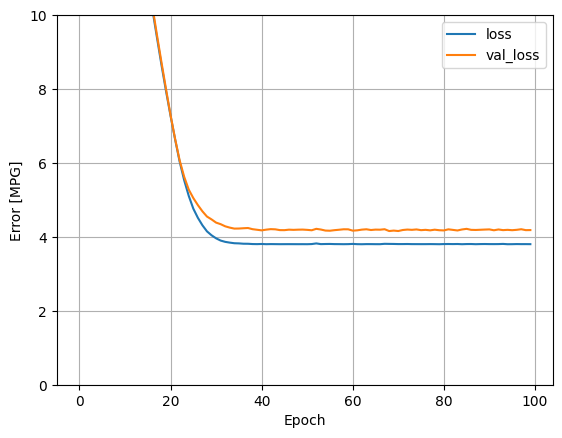

In [ ]:
plot_loss(history)

### Evaluation on the test set

Model evaluation and results saving on a dedicated dictionary.

In [ ]:
test_results = {}

test_results['horsepower_model'] = horsepower_model.evaluate(
    test_features['Horsepower'],
    test_labels, verbose=0)

Visualization of predictions with respect to inputs

In [ ]:
x = tf.linspace(0.0, 250, 251)
y = horsepower_model.predict(x)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


In [ ]:
def plot_horsepower(x, y):
  plt.scatter(train_features['Horsepower'], train_labels, label='Data')
  plt.plot(x, y, color='k', label='Predictions')
  plt.xlabel('Horsepower')
  plt.ylabel('MPG')
  plt.legend()

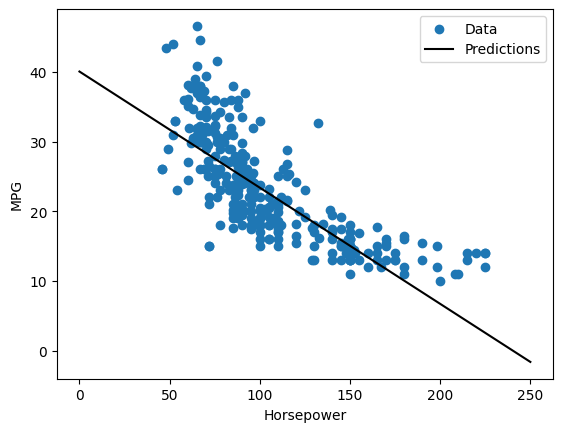

In [ ]:
plot_horsepower(x, y)

### Linear regression with multiple inputs

Building the model by considering all the attributes.

In [ ]:
input_shape = [train_features.shape[1],]
input_layer = tf.keras.layers.Input(shape=input_shape)

normalizer = tf.keras.layers.Normalization(input_shape=[1,], axis=None)
normalizer.adapt(np.array(train_features))
normalization_layer = normalizer(input_layer)

dense_layer = tf.keras.layers.Dense(units=1)(normalization_layer)

linear_model = tf.keras.Model(input_layer, dense_layer)
linear_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_2 (Normalization) │ (None, 9)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13 (56.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 3 (16.00 B)

Configuration and training

In [ ]:
linear_model.compile(
    optimizer=tf.optimizers.Adam(learning_rate=0.1),
    loss='mean_absolute_error')

In [ ]:
%%time
history = linear_model.fit(
    train_features,
    train_labels,
    epochs=100,
    # Suppress logging.
    verbose=0,
    # Calculate validation results on 20% of the training data.
    validation_split = 0.2)

CPU times: user 10.1 s, sys: 2.19 s, total: 12.3 s
Wall time: 12.6 s


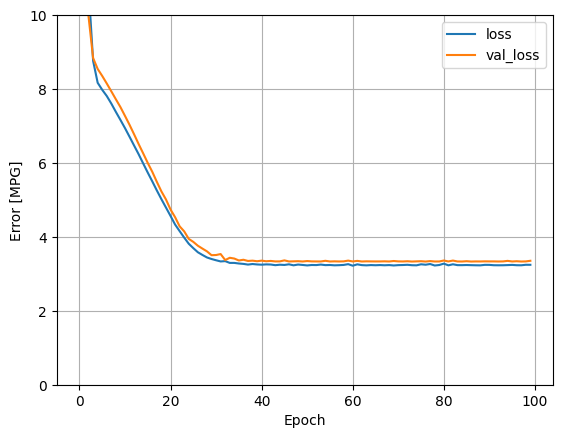

In [ ]:
plot_loss(history)

Evaluation on the test set and saving in the dictionary.

In [ ]:
test_results['linear_model'] = linear_model.evaluate(
    test_features, test_labels, verbose=0)

## Regression with a multi-layers perceptron (MLP)

Creation of a dedicated function to build a model and configure it. It takes as parameters the normalization information to handle both cases (1 attribute and all attributes).

The model contrains two hidden layers between inputs and outputs.

The model contains some additional layers in comparison to the linear model:

* The normalization layer, as before (with `horsepower_normalizer` for a single input and `normalizer` for multiple inputs).
* Two non-linear hidden layers (`Dense` layers) with a ReLU (`relu`) activation function.
* A final dense layer (`Dense`) for the output.

Both models will use the same training procedure so the `compile` method is included in the `build_and_compile_model` function.

In [ ]:
def build_and_compile_model(input_shape,norm):
  input_layer = tf.keras.layers.Input(shape=input_shape)
  normalization_layer = norm(input_layer)
  hidden_layer1 = tf.keras.layers.Dense(64, activation='relu')(normalization_layer)
  hidden_layer2 = tf.keras.layers.Dense(64, activation='relu')(hidden_layer1)
  output_layer = tf.keras.layers.Dense(1)(hidden_layer2)

  model = tf.keras.Model(input_layer, output_layer)
  model.compile(loss='mean_absolute_error',
                optimizer=tf.keras.optimizers.Adam(0.001))

  return model

### Regression with a MLP on a single attribute

MLP model taking the attribute `'Horsepower'` as input and the normalization layer `horsepower_normalizer` (defined before).

In [ ]:
# not required if already done before
horsepower = np.array(train_features['Horsepower'])
horsepower_normalizer = tf.keras.layers.Normalization(input_shape=[1,], axis=None)
horsepower_normalizer.adapt(horsepower)
input_shape = [1,]

dnn_horsepower_model = build_and_compile_model(input_shape, horsepower_normalizer)
dnn_horsepower_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_3 (Normalization) │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,356 (17.02 KB)

 Trainable params: 4,353 (17.00 KB)

 Non-trainable params: 3 (16.00 B)

Training

In [ ]:
%%time
history = dnn_horsepower_model.fit(
    train_features['Horsepower'],
    train_labels,
    validation_split=0.2,
    verbose=0, epochs=100)

CPU times: user 11.6 s, sys: 2.31 s, total: 13.9 s
Wall time: 16.4 s


Loss curves

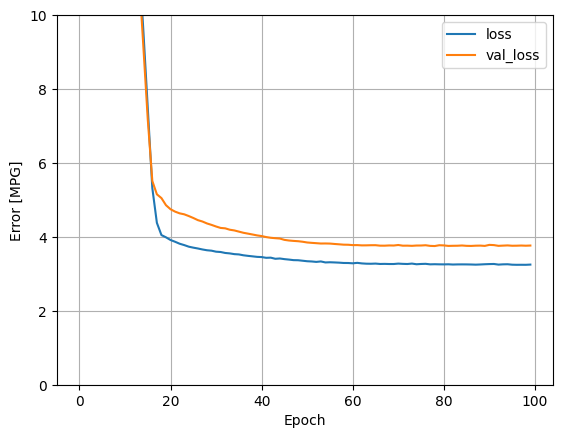

In [ ]:
plot_loss(history)

It is possible to display the predictions with respect to the input (attribute `'Horsepower'`). We can see that the model is now able to do non-linear predictions.

In [ ]:
x = tf.linspace(0.0, 250, 251)
y = dnn_horsepower_model.predict(x)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


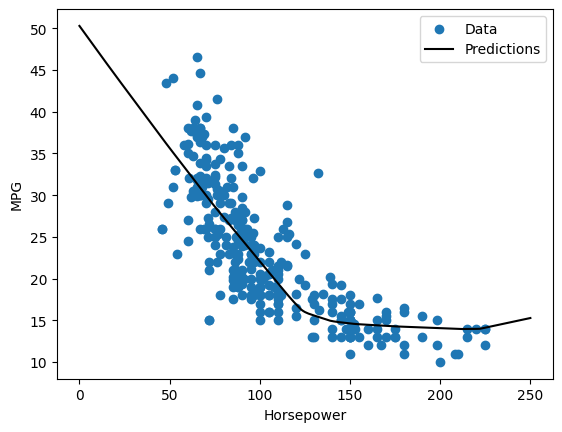

In [ ]:
plot_horsepower(x, y)

Evaluation on the test set

In [ ]:
test_results['dnn_horsepower_model'] = dnn_horsepower_model.evaluate(
    test_features['Horsepower'], test_labels,
    verbose=0)

### Regression with a MLP on multiple attributes

In [ ]:
# not required if already done
input_shape = [train_features.shape[1],]
normalizer = tf.keras.layers.Normalization(input_shape=[1,], axis=None)
normalizer.adapt(np.array(train_features))

dnn_model = build_and_compile_model(input_shape,normalizer)
dnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_4 (Normalization) │ (None, 9)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,868 (19.02 KB)

 Trainable params: 4,865 (19.00 KB)

 Non-trainable params: 3 (16.00 B)

In [ ]:
%%time
history = dnn_model.fit(
    train_features,
    train_labels,
    validation_split=0.2,
    verbose=0, epochs=100)

CPU times: user 12.3 s, sys: 2.28 s, total: 14.6 s
Wall time: 19.2 s


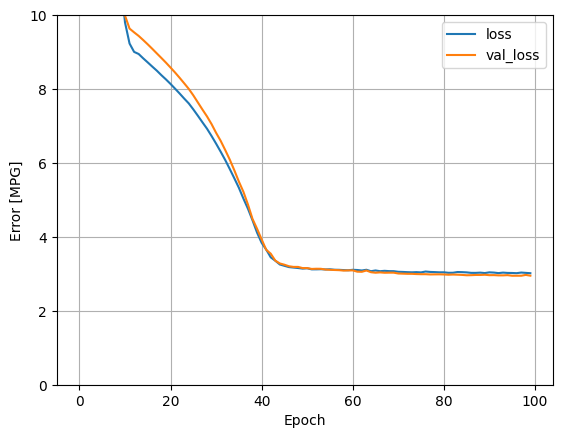

In [ ]:
plot_loss(history)

Evaluation on the test set

In [ ]:
test_results['dnn_model'] = dnn_model.evaluate(test_features, test_labels, verbose=0)

## Performance

Once all model have been trained we can compare their performance saved in our dictionary. The MLP model on all attributes seems to be the best performing.

In [ ]:
pd.DataFrame(test_results, index=['Mean absolute error [MPG]']).T

,Mean absolute error [MPG]
horsepower_model,3.651197
linear_model,3.149744
dnn_horsepower_model,2.908866
dnn_model,2.809300


### Prédictions on the test set

We can now make the predictions by using the best model and visualize these predictions with respect to true values.

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


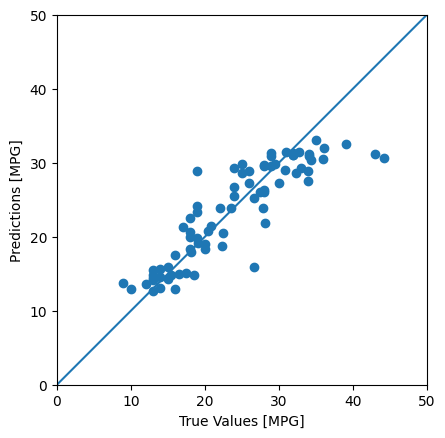

In [ ]:
test_predictions = dnn_model.predict(test_features).flatten()

a = plt.axes(aspect='equal')
plt.scatter(test_labels, test_predictions)
plt.xlabel('True Values [MPG]')
plt.ylabel('Predictions [MPG]')
lims = [0, 50]
plt.xlim(lims)
plt.ylim(lims)
_ = plt.plot(lims, lims)


It can also be interesting to visualize the distribution of the errors.

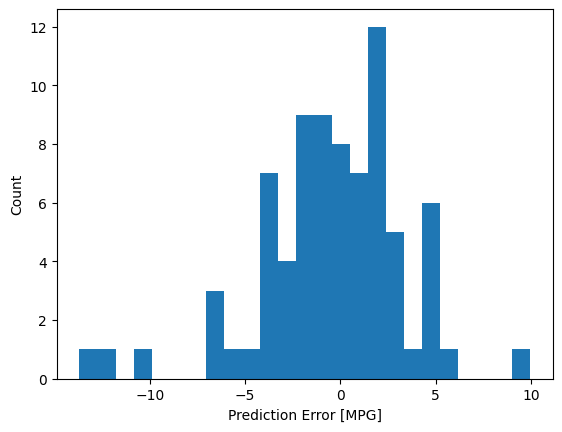

In [ ]:
error = test_predictions - test_labels
plt.hist(error, bins=25)
plt.xlabel('Prediction Error [MPG]')
_ = plt.ylabel('Count')

### Saving the best model

For information, we can save the trained model to use it later.

In [ ]:
dnn_model.save('dnn_model.keras')

## Trained parameters' analysis

Once the model has been trained, it is possible to analyze which information is going through the model and how. Each layer contains a list of parameters, usually of length 2 corresponding to $w$ and $b$.

### Get the biais $b$ from the first dense layer

In [ ]:
dnn_model.layers[2].weights[1].shape

TensorShape([64])

### Get the weights $w$ from the first dense layer

In [ ]:
dnn_model.layers[2].weights[0].shape

TensorShape([9, 64])

### Weights visualization

Weights linking all attributes to the first hidden neuron.

In [ ]:
sns.color_palette("deep")

[(0.2980392156862745, 0.4470588235294118, 0.6901960784313725),
 (0.8666666666666667, 0.5176470588235295, 0.3215686274509804),
 (0.3333333333333333, 0.6588235294117647, 0.40784313725490196),
 (0.7686274509803922, 0.3058823529411765, 0.3215686274509804),
 (0.5058823529411764, 0.4470588235294118, 0.7019607843137254),
 (0.5764705882352941, 0.47058823529411764, 0.3764705882352941),
 (0.8549019607843137, 0.5450980392156862, 0.7647058823529411),
 (0.5490196078431373, 0.5490196078431373, 0.5490196078431373),
 (0.8, 0.7254901960784313, 0.4549019607843137),
 (0.39215686274509803, 0.7098039215686275, 0.803921568627451)]

/tmp/ipython-input-1668102847.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=np.arange(weights.shape[0]), y=weights, palette=sns.color_palette("deep"))
/tmp/ipython-input-1668102847.py:2: UserWarning: The palette list has more values (10) than needed (9), which may not be intended.
  sns.barplot(x=np.arange(weights.shape[0]), y=weights, palette=sns.color_palette("deep"))


<Axes: >

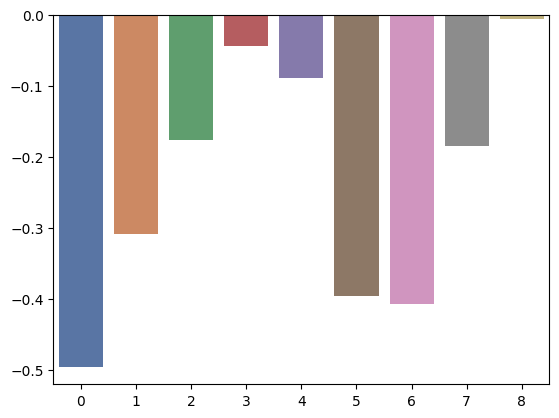

In [ ]:
weights = np.asarray(dnn_model.layers[2].weights[0][:,0])
sns.barplot(x=np.arange(weights.shape[0]), y=weights, palette=sns.color_palette("deep"))

Weights linking the first attribute to all hidden neurons of the first dense layer.

/tmp/ipython-input-721459016.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=np.arange(weights.shape[0]), y=weights, palette=sns.color_palette("deep"))
/tmp/ipython-input-721459016.py:2: UserWarning: 
The palette list has fewer values (10) than needed (64) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=np.arange(weights.shape[0]), y=weights, palette=sns.color_palette("deep"))


<Axes: >

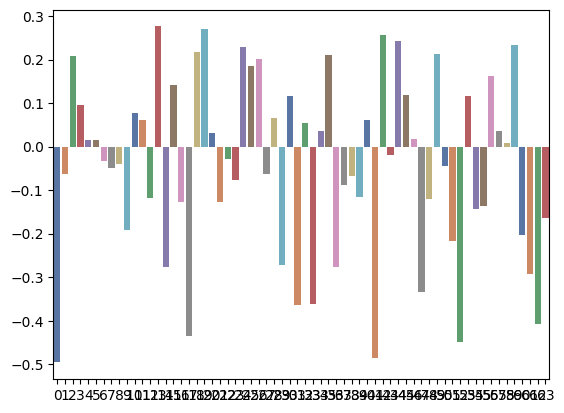

In [ ]:
weights = np.asarray(dnn_model.layers[2].weights[0][0,:])
sns.barplot(x=np.arange(weights.shape[0]), y=weights, palette=sns.color_palette("deep"))